In [2]:
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt


def get_sdss_spectrum(ra, dec, radius=2.0, plot=True):
    """
    Fetch and optionally plot an SDSS spectrum.

    Parameters
    ----------
    ra, dec : float
        ICRS coordinates in degrees
    radius : float
        Search radius in arcsec
    plot : bool
        If True, plot the spectrum

    Returns
    -------
    wave, flux, error : ndarray or None
    """
    pos = SkyCoord(ra, dec, unit="deg", frame="icrs")
    xid = SDSS.query_region(pos, spectro=True, radius=radius * u.arcsec)

    if xid is None or len(xid) == 0:
        print("No SDSS spectroscopy found.")
        return None, None, None

    spectra = SDSS.get_spectra(matches=xid)
    if not spectra:
        print("SDSS spectra query returned nothing.")
        return None, None, None

    spec = spectra[0][1].data

    wave = 10 ** spec["loglam"]
    flux = spec["flux"]

    if "ivar" in spec.names:
        ivar = spec["ivar"]
        error = np.full_like(ivar, np.nan)
        mask = ivar > 0
        error[mask] = 1.0 / np.sqrt(ivar[mask])
    else:
        error = None

    # -------- Plot --------
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(wave, flux, color="black", lw=1, label="SDSS")

        if error is not None:
            plt.fill_between(
                wave,
                flux - error,
                flux + error,
                color="gray",
                alpha=0.3,
                label="1σ uncertainty"
            )

        plt.xlabel("Wavelength [Å]")
        plt.ylabel("Flux")
        plt.title(f"SDSS Spectrum\nRA={ra:.5f}, Dec={dec:.5f}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return wave, flux, error


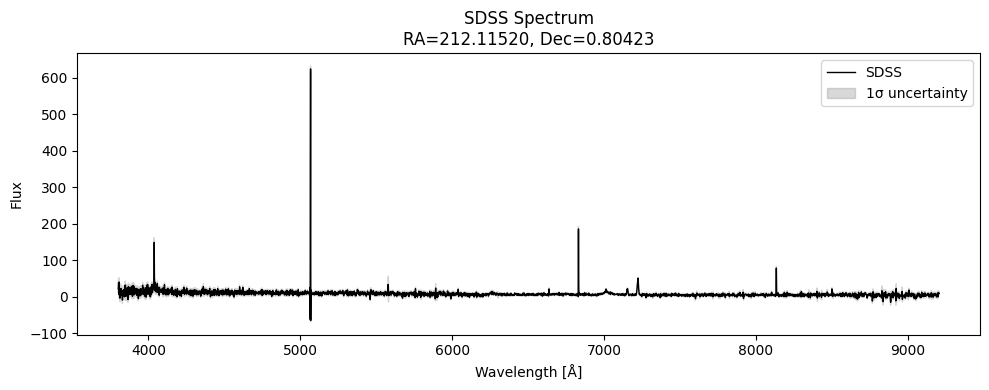

(array([3801.8933, 3802.77  , 3803.6448, ..., 9200.257 , 9202.379 ,
        9204.495 ], dtype=float32),
 array([21.138489 , 34.40533  , 38.04471  , ...,  5.7492676, 11.401796 ,
         8.929532 ], dtype='>f4'),
 array([11.349383 , 11.606631 , 11.608885 , ...,  4.8744845,  5.053876 ,
         5.038977 ], dtype='>f4'))

In [3]:
get_sdss_spectrum(212.1152, 0.80423)